💡 **Environment:** `clamp-analyses`

# ARCHS4 CRISPR-Cas9 - Tissue Inference for LV702

This notebook infers the tissue and cell-type of the LVs by examining ARCHS4 samples. The top 1% of samples (by B-matrix score) are connected to the ARCHS4 HDF5 file to infer the GEO metadata and infer the tissue/cell using ARCHS4 R package.

## Libraries

In [1]:
library(here)
library(dplyr)
library(tibble)
library(tidyr)
library(stringr)
library(ggplot2)
library(archs4r)

here() starts at /home/msubirana/Documents/pivlab/clamp-analyses




Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Loading required package: rhdf5



...

for more help type ?bit64




Attaching package: ‘bit64’




The following object is masked from ‘package:utils’:

    hashtab




The following objects are masked from ‘package:base’:

    :, %in%, colSums, is.double, match, order, rank, rowSums




Loading required package: jsonlite



## Input

In [2]:
h5file <- here('data/archs4/human_gene_v2.5.h5')
archs4_CLAMPfull <- readRDS(here('output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100/hall_coverage_rs100_seed_1/CLAMPfull_hall.rds'))

## Matrix B sample weights

In [3]:
archs4_B <- as.matrix(archs4_CLAMPfull$B)
dim(archs4_B)
archs4_CLAMPfull <- NULL

[1]   1728 605614

## Top samples for LV702

In [4]:
LV_ID <- 'LV702'

lv_vec   <- sort(archs4_B[LV_ID, ], decreasing = TRUE)
n_top    <- ceiling(length(lv_vec) * 0.01)

top_samples <- names(lv_vec)[seq_len(n_top)]
cat('Total samples in B:', length(lv_vec), '\n')
cat('Top 1% count:', n_top, '\n')
cat('First 5 sample IDs:', paste(head(top_samples, 5), collapse = ', '), '\n')

Total samples in B: 605614 


Top 1% count: 6057 


First 5 sample IDs: GSM2625603, GSM3248128, GSM3248203, GSM3169859, GSM3447400 


In [5]:
head(lv_vec, 20)

GSM2625603 GSM3248128 GSM3248203 GSM3169859 GSM3447400 GSM4608606 GSM3448119 
 0.1636341  0.1622486  0.1559852  0.1546505  0.1434019  0.1344224  0.1338038 
GSM3328492 GSM3319042 GSM3247954 GSM3336656 GSM3453525 GSM2618865 GSM2835536 
 0.1332089  0.1298433  0.1267457  0.1240914  0.1223551  0.1219327  0.1193257 
GSM3316234 GSM2313712 GSM4406810 GSM3447453 GSM3314096 GSM3440851 
 0.1190958  0.1186205  0.1177637  0.1173083  0.1163690  0.1161589

## Retrieve metadata via archs4r

In [6]:
meta_fields <- c('geo_accession', 'series_id', 'title',
                 'source_name_ch1', 'characteristics_ch1')

meta_top <- as.data.frame(
  a4.meta.samples(h5file, top_samples, meta_fields = meta_fields, silent = TRUE),
  stringsAsFactors = FALSE
)

meta_top <- meta_top[top_samples, ]
meta_top$rank    <- seq_len(nrow(meta_top))
meta_top$B_score <- lv_vec[rownames(meta_top)]

dim(meta_top)
head(meta_top, 50)

[1] 6057    7

,geo_accession,series_id,title,source_name_ch1,characteristics_ch1,rank,B_score
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
GSM2625603,GSM2625603,GSE98887,P06_C10R28 Non-diabetic human islet single cell,Isolated single cells from type-2 diabetes human islets,tissue: inlet cells,1,0.1636341
GSM3248128,GSM3248128,GSE116672,1001701405_D4,blood (PBMCs),"tissue: blood,patient id: 1-013,cell type: unknown,Sex: F,diseaseseverity: severe dengue,numberhumanuniquelymappedreads: 3941,numbervirusreads: 0,age: 31",2,0.1622486
GSM3248203,GSM3248203,GSE116672,1001701405_G10,blood (PBMCs),"tissue: blood,patient id: 1-013,cell type: unknown,Sex: F,diseaseseverity: severe dengue,numberhumanuniquelymappedreads: 20687,numbervirusreads: 0,age: 31",3,0.1559852
GSM3169859,GSM3169859,"GSE115214,GSE115218",C21_01_S3 [colonies_scRNA-seq],donor 1_CD34+ hematopoietic cells,"donor id: donor 1,cell type: primary hematopoietic cells",4,0.1546505
GSM3447400,GSM3447400,GSE121827,ACCLAIM_509364_0_Tfh,PBMC,"cell type: Tfh,tissue: PBMC,participantid: ACCLAIM_509364,visitnumber: 0,barcode: 951945,randomized treatment: Abatacept,age: 35,Sex: Female,race: White",5,0.1434019
GSM4608606,GSM4608606,"GSE152197,GSE152543",8BTreg54,iTreg,"donor id: 8BTreg,tissue: Blood,age at procedure: 46,date of procedure: 3/17/07,year diagnosed: -1,height (cm): 158,weight (kg): 62,bmi: 24.84,Sex: F,donor group: HC",6,0.1344224
GSM3448119,GSM3448119,GSE121862,Library NK26,adult kidney,"experiment: 20171214A,barcode: N707,ppid: 3431,region: Cortex,tissue collection: lap nephrectomy,tissue processing: 30 minutes Papain-Collagenase,Sex: M,source: Washington University,cell type: mixed sample (non-demultiplexed)",7,0.1338038
GSM3328492,GSM3328492,GSE118412,RC17_after_mesDA_28_C9,Human graft in rat brain,"cell type: RC17,rat_id: B,sortingmethod: GFP,plate: RC17_after_mesDA_28,ercc_added: 0.025",8,0.1332089
GSM3319042,GSM3319042,GSE118127,sample_3-15,Adult Ovary Tissue,"patient id: P3,batch: 2,tissue: Follicle 1-2mm",9,0.1298433


## Collapse by GEO series

Collapse top samples before tissue inference so repeated samples from the same GEO study contribute one vote. If one GSM belongs to multiple GSE accessions, keep it as one vote using the first/primary GSE and retain all GSEs in `series_id_all`. The representative metadata is taken from the highest-ranked sample in each primary `series_id`, while `max_B_score`, `median_B_score`, and `n_samples` summarize the series.

In [7]:
meta_top_series <- meta_top %>%
  tibble::rownames_to_column('sample_id') %>%
  dplyr::mutate(
    series_id_all = stringr::str_remove_all(series_id, '\\s+'),
    series_id_primary = stringr::str_extract(series_id_all, '^[^,]+')
  ) %>%
  dplyr::filter(!is.na(series_id_primary), series_id_primary != '') %>%
  dplyr::arrange(rank) %>%
  dplyr::group_by(series_id_primary) %>%
  dplyr::summarise(
    series_id = dplyr::first(series_id_primary),
    series_id_all = paste(sort(unique(series_id_all)), collapse = ';'),
    n_samples = dplyr::n_distinct(sample_id),
    best_rank = min(rank, na.rm = TRUE),
    max_B_score = max(B_score, na.rm = TRUE),
    median_B_score = median(B_score, na.rm = TRUE),
    sample_id = sample_id[which.min(rank)],
    geo_accession = geo_accession[which.min(rank)],
    title = title[which.min(rank)],
    source_name_ch1 = source_name_ch1[which.min(rank)],
    characteristics_ch1 = characteristics_ch1[which.min(rank)],
    .groups = 'drop'
  ) %>%
  dplyr::arrange(best_rank) %>%
  dplyr::mutate(
    rank = best_rank,
    B_score = max_B_score
  )

cat('Top samples before series collapse:', nrow(meta_top), '\n')
cat('Primary GEO series after collapse:', nrow(meta_top_series), '\n')

meta_top_series %>%
  dplyr::select(series_id, series_id_all, n_samples, best_rank, max_B_score,
                median_B_score, sample_id, source_name_ch1) %>%
  dplyr::slice_head(n = 50)

Top samples before series collapse: 6057 


Primary GEO series after collapse: 1347 


series_id,series_id_all,n_samples,best_rank,max_B_score,median_B_score,sample_id,source_name_ch1
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>
GSE98887,GSE98887,110,1,0.16363410,0.05814447,GSM2625603,Isolated single cells from type-2 diabetes human islets
GSE116672,GSE116672,159,2,0.16224860,0.05412933,GSM3248128,blood (PBMCs)
GSE115214,"GSE115214,GSE115218",17,4,0.15465054,0.05291972,GSM3169859,donor 1_CD34+ hematopoietic cells
GSE121827,GSE121827,4,5,0.14340193,0.09289940,GSM3447400,PBMC
GSE152197,"GSE152197,GSE152543",185,6,0.13442238,0.04909261,GSM4608606,iTreg
GSE121862,GSE121862,1,7,0.13380378,0.13380378,GSM3448119,adult kidney
GSE118412,GSE118412,14,8,0.13320886,0.07138664,GSM3328492,Human graft in rat brain
GSE118127,GSE118127,1,9,0.12984332,0.12984332,GSM3319042,Adult Ovary Tissue
GSE118691,GSE118691,1,11,0.12409141,0.12409141,GSM3336656,cell


## Top source labels: raw and collapsed


In [8]:
tissue_df_raw <- meta_top %>%
  dplyr::mutate(
    source_clean = stringr::str_to_lower(stringr::str_trim(source_name_ch1))
  ) %>%
  dplyr::count(source_clean, sort = TRUE) %>%
  dplyr::slice_head(n = 50)

tissue_df_series <- meta_top_series %>%
  dplyr::mutate(
    source_clean = stringr::str_to_lower(stringr::str_trim(source_name_ch1))
  ) %>%
  dplyr::count(source_clean, sort = TRUE) %>%
  dplyr::slice_head(n = 50)

cat('Raw top samples (not collapsed):\n')
print(tissue_df_raw)

cat('\nCollapsed by primary GEO series:\n')
print(tissue_df_series)

Raw top samples (not collapsed):


                                                             source_clean   n
1                                                                   itreg 185
2                                                              stem cells 164
3                                                           blood (pbmcs) 159
4                                                                    pbmc 134
5                                                        lcl-derived ipsc 132
6                                                                   blood  82
7                                                                blastoid  80
8                          isolated single cells from normal human islets  72
9                                                        psoriasis lesion  69
10                                                            whole blood  61
11                                                            bone marrow  59
12                                          cultured embryonic s


Collapsed by primary GEO series:


# A tibble: 50 × 2
   source_clean                           n
   <chr>                              <int>
 1 blood                                 18
 2 whole blood                           17
 3 pbmc                                  16
 4 bone marrow                           12
 5 cell line                             12
 6 peripheral blood                       9
 7 breast cancer cells                    7
 8 peripheral blood mononuclear cells     7
 9 breast cancer cell line                6
10 hela cells                             6
# ℹ 40 more rows


## HepG2 enrichment in top 1%

Test whether HepG2-labeled ARCHS4 samples are overrepresented in the LV702 top 1%. The sample-level test uses all B-matrix samples as background. The series-level test collapses to the primary GEO series so one repeated study does not dominate.

In [9]:
read_archs4_sample_meta_h5 <- function(h5file, samples, meta_fields) {
  if (!requireNamespace('hdf5r', quietly = TRUE)) {
    stop('Package hdf5r is required to read all ARCHS4 sample metadata for enrichment.')
  }

  h5 <- hdf5r::H5File$new(h5file, mode = 'r')
  on.exit(h5$close_all())

  geo_all <- h5[['meta/samples/geo_accession']][]
  idx <- match(samples, geo_all)
  if (anyNA(idx)) {
    warning(sum(is.na(idx)), ' requested samples were not found in ARCHS4 metadata.')
  }

  out <- data.frame(sample_id = samples, stringsAsFactors = FALSE)
  for (field in meta_fields) {
    vals <- h5[[paste0('meta/samples/', field)]][]
    out[[field]] <- vals[idx]
  }
  out
}

is_hepg2_sample <- function(df) {
  text <- stringr::str_to_lower(paste(df$title, df$source_name_ch1, df$characteristics_ch1, sep = ' | '))
  stringr::str_detect(text, '\\bhepg2\\b|hep g2|hep-g2')
}

meta_all_hepg2 <- read_archs4_sample_meta_h5(
  h5file,
  samples = names(lv_vec),
  meta_fields = meta_fields
) %>%
  dplyr::mutate(
    rank = dplyr::row_number(),
    B_score = as.numeric(lv_vec),
    is_top1 = rank <= n_top,
    is_hepg2 = is_hepg2_sample(.)
  )

hepg2_sample_top <- sum(meta_all_hepg2$is_top1 & meta_all_hepg2$is_hepg2, na.rm = TRUE)
hepg2_sample_bg <- sum(meta_all_hepg2$is_hepg2, na.rm = TRUE)
n_sample_top <- sum(meta_all_hepg2$is_top1, na.rm = TRUE)
n_sample_bg <- nrow(meta_all_hepg2)

hepg2_sample_mat <- matrix(
  c(
    hepg2_sample_top,
    n_sample_top - hepg2_sample_top,
    hepg2_sample_bg - hepg2_sample_top,
    (n_sample_bg - n_sample_top) - (hepg2_sample_bg - hepg2_sample_top)
  ),
  nrow = 2,
  byrow = TRUE,
  dimnames = list(c('top_1pct', 'not_top_1pct'), c('HepG2', 'not_HepG2'))
)

hepg2_sample_test <- fisher.test(hepg2_sample_mat, alternative = 'greater')
hepg2_sample_enrichment <- tibble::tibble(
  level = 'sample',
  top_hepg2 = hepg2_sample_top,
  top_total = n_sample_top,
  background_hepg2 = hepg2_sample_bg,
  background_total = n_sample_bg,
  top_fraction = hepg2_sample_top / n_sample_top,
  background_fraction = hepg2_sample_bg / n_sample_bg,
  fold_enrichment = top_fraction / background_fraction,
  odds_ratio = unname(hepg2_sample_test$estimate),
  pvalue = hepg2_sample_test$p.value
)

meta_all_hepg2_series <- meta_all_hepg2 %>%
  dplyr::mutate(
    series_id_all = stringr::str_remove_all(series_id, '\\s+'),
    series_id_primary = stringr::str_extract(series_id_all, '^[^,]+')
  ) %>%
  dplyr::filter(!is.na(series_id_primary), series_id_primary != '') %>%
  dplyr::group_by(series_id_primary) %>%
  dplyr::summarise(
    n_samples = dplyr::n_distinct(sample_id),
    is_top1 = any(is_top1, na.rm = TRUE),
    is_hepg2 = any(is_hepg2, na.rm = TRUE),
    is_top1_hepg2 = any(is_top1 & is_hepg2, na.rm = TRUE),
    best_rank = min(rank, na.rm = TRUE),
    best_hepg2_rank = suppressWarnings(min(rank[is_hepg2], na.rm = TRUE)),
    max_B_score = max(B_score, na.rm = TRUE),
    max_hepg2_B_score = suppressWarnings(max(B_score[is_hepg2], na.rm = TRUE)),
    example_sample = sample_id[which.min(rank)],
    example_source = source_name_ch1[which.min(rank)],
    example_hepg2_sample = sample_id[which.min(ifelse(is_hepg2, rank, Inf))],
    example_hepg2_source = source_name_ch1[which.min(ifelse(is_hepg2, rank, Inf))],
    .groups = 'drop'
  ) %>%
  dplyr::mutate(
    best_hepg2_rank = dplyr::if_else(is.infinite(best_hepg2_rank), NA_real_, best_hepg2_rank),
    max_hepg2_B_score = dplyr::if_else(is.infinite(max_hepg2_B_score), NA_real_, max_hepg2_B_score)
  )

hepg2_series_top <- sum(meta_all_hepg2_series$is_top1_hepg2, na.rm = TRUE)
hepg2_series_bg <- sum(meta_all_hepg2_series$is_hepg2, na.rm = TRUE)
n_series_top <- sum(meta_all_hepg2_series$is_top1, na.rm = TRUE)
n_series_bg <- nrow(meta_all_hepg2_series)
hepg2_series_not_top <- sum(!meta_all_hepg2_series$is_top1 & meta_all_hepg2_series$is_hepg2, na.rm = TRUE)
not_hepg2_series_not_top <- sum(!meta_all_hepg2_series$is_top1 & !meta_all_hepg2_series$is_hepg2, na.rm = TRUE)

hepg2_series_mat <- matrix(
  c(
    hepg2_series_top,
    n_series_top - hepg2_series_top,
    hepg2_series_not_top,
    not_hepg2_series_not_top
  ),
  nrow = 2,
  byrow = TRUE,
  dimnames = list(c('top_1pct', 'not_top_1pct'), c('HepG2', 'not_HepG2'))
)

hepg2_series_test <- fisher.test(hepg2_series_mat, alternative = 'greater')
hepg2_series_enrichment <- tibble::tibble(
  level = 'primary_GEO_series',
  top_hepg2 = hepg2_series_top,
  top_total = n_series_top,
  background_hepg2 = hepg2_series_bg,
  background_total = n_series_bg,
  top_fraction = hepg2_series_top / n_series_top,
  background_fraction = hepg2_series_bg / n_series_bg,
  fold_enrichment = top_fraction / background_fraction,
  odds_ratio = unname(hepg2_series_test$estimate),
  pvalue = hepg2_series_test$p.value
)

hepg2_enrichment <- dplyr::bind_rows(hepg2_sample_enrichment, hepg2_series_enrichment)
print(hepg2_enrichment)

cat('\nHepG2 samples in top 1%:\n')
meta_all_hepg2 %>%
  dplyr::filter(is_top1, is_hepg2) %>%
  dplyr::arrange(rank) %>%
  dplyr::select(sample_id, series_id, rank, B_score, title, source_name_ch1, characteristics_ch1) %>%
  dplyr::slice_head(n = 50)

cat('\nTop HepG2 samples across all B samples:\n')
meta_all_hepg2 %>%
  dplyr::filter(is_hepg2) %>%
  dplyr::arrange(rank) %>%
  dplyr::select(sample_id, series_id, rank, B_score, title, source_name_ch1, characteristics_ch1) %>%
  dplyr::slice_head(n = 50)

# A tibble: 2 × 10
  level       top_hepg2 top_total background_hepg2 background_total top_fraction
  <chr>           <int>     <int>            <int>            <int>        <dbl>
1 sample             45      6057             2656           605614      0.00743
2 primary_GE…        20      1347              583            17991      0.0148 
# ℹ 4 more variables: background_fraction <dbl>, fold_enrichment <dbl>,
#   odds_ratio <dbl>, pvalue <dbl>



HepG2 samples in top 1%:


sample_id,series_id,rank,B_score,title,source_name_ch1,characteristics_ch1
<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>
GSM3443192,"GSE121667,GSE121668",28,0.11274513,HepG2-RNF2-BE3-rep3,HepG2,"cell line: HepG2,treatment: BE3-P2A-EGFP,guide: RNF2 site 1: GTCATCTTAGTCATTACCTG(AGG),gfp: Top 5%"
GSM3304502,GSE117594,106,0.08981796,POOL1__pMPRA1__HepG2__rep11,HepG2 cell line,sample type: GFP-RNA
GSM5271121,GSE173576,120,0.08756094,Ctrl_1,HepG2/NTCP,"cell line: Hepatoma cell line,treatment: Ctrl,passage number: 12,selection marker: Blasticidin"
GSM3577350,"GSE125570,GSE125571",169,0.08196770,Trog0.2uM2hrA,HepG2,"tissue: HepG2 cells,passage: 6-8,genotype: ATCC HB-8065,treatment: 0.2uM Trog, 2hr"
GSM3304503,GSE117594,717,0.06531029,POOL1__pMPRA1__HepG2__rep12,HepG2 cell line,sample type: GFP-RNA
GSM4629018,GSE152883,1344,0.05918912,C1,HepG2 cells,"cell line: human liver carcinoma cell line HepG2,treatment: untreated"
GSM5375106,GSE177495,1577,0.05758516,CRISPR RNA-seq from HepG2 (ENCLB758JWQ),Homo sapiens HepG2 cell line genetically modified (deletion) using CRISPR targeting RPL11,"antibody: RPL11,line: HepG2,biomaterial_type: cell line,description: RNA-seq on HepG2 cells treated with a CRISPR gRNA against RPL11. (RPL11-BGHcLV16-47),biosample encode accession: ENCBS252VWD (SAMN19596698),Sex: male,health state: hepatocellular carcinoma,dev stage: child,age: 15 year,donor_id: ENCDO000AAC,lab: Brenton Graveley, UConn,source: ATCC,link: ENCBS252VWD at ENCODE; https://www.encodeproject.org/ENCBS252VWD/,link: Derived from ENCODE donor ENCDO000AAC; https://www.encodeproject.org/ENCDO000AAC/"
GSM3304527,GSE117594,1592,0.05749838,POOL2__pMPRA1__HepG2__rep8,HepG2 cell line,sample type: GFP-RNA
GSM3304515,GSE117594,1729,0.05656189,POOL1__pNoCMVMPRA1__HepG2__rep4,HepG2 cell line,sample type: GFP-RNA



Top HepG2 samples across all B samples:


sample_id,series_id,rank,B_score,title,source_name_ch1,characteristics_ch1
<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>
GSM3443192,"GSE121667,GSE121668",28,0.11274513,HepG2-RNF2-BE3-rep3,HepG2,"cell line: HepG2,treatment: BE3-P2A-EGFP,guide: RNF2 site 1: GTCATCTTAGTCATTACCTG(AGG),gfp: Top 5%"
GSM3304502,GSE117594,106,0.08981796,POOL1__pMPRA1__HepG2__rep11,HepG2 cell line,sample type: GFP-RNA
GSM5271121,GSE173576,120,0.08756094,Ctrl_1,HepG2/NTCP,"cell line: Hepatoma cell line,treatment: Ctrl,passage number: 12,selection marker: Blasticidin"
GSM3577350,"GSE125570,GSE125571",169,0.08196770,Trog0.2uM2hrA,HepG2,"tissue: HepG2 cells,passage: 6-8,genotype: ATCC HB-8065,treatment: 0.2uM Trog, 2hr"
GSM3304503,GSE117594,717,0.06531029,POOL1__pMPRA1__HepG2__rep12,HepG2 cell line,sample type: GFP-RNA
GSM4629018,GSE152883,1344,0.05918912,C1,HepG2 cells,"cell line: human liver carcinoma cell line HepG2,treatment: untreated"
GSM5375106,GSE177495,1577,0.05758516,CRISPR RNA-seq from HepG2 (ENCLB758JWQ),Homo sapiens HepG2 cell line genetically modified (deletion) using CRISPR targeting RPL11,"antibody: RPL11,line: HepG2,biomaterial_type: cell line,description: RNA-seq on HepG2 cells treated with a CRISPR gRNA against RPL11. (RPL11-BGHcLV16-47),biosample encode accession: ENCBS252VWD (SAMN19596698),Sex: male,health state: hepatocellular carcinoma,dev stage: child,age: 15 year,donor_id: ENCDO000AAC,lab: Brenton Graveley, UConn,source: ATCC,link: ENCBS252VWD at ENCODE; https://www.encodeproject.org/ENCBS252VWD/,link: Derived from ENCODE donor ENCDO000AAC; https://www.encodeproject.org/ENCDO000AAC/"
GSM3304527,GSE117594,1592,0.05749838,POOL2__pMPRA1__HepG2__rep8,HepG2 cell line,sample type: GFP-RNA
GSM3304515,GSE117594,1729,0.05656189,POOL1__pNoCMVMPRA1__HepG2__rep4,HepG2 cell line,sample type: GFP-RNA


In [10]:
output_dir <- here('output/03_model_biology/00_archs4/01_CRISPRCas9/02_tissue_inference')
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)
readr::write_csv(hepg2_enrichment, file.path(output_dir, 'lv702_hepg2_enrichment.csv'))
cat('Saved lv702_hepg2_enrichment.csv to', output_dir, '\n')

Saved lv702_hepg2_enrichment.csv to /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/01_CRISPRCas9/02_tissue_inference 


## PhenoPlier-style cell-type / tissue strip plot

Adapts the [PhenoPlier tissue inference approach](https://github.com/greenelab/phenoplier/blob/main/nbs/99_demo/02-LV_cell_types-LV603.ipynb) to ARCHS4 + R, building on the `meta_top` metadata already retrieved above.

**How it differs from the sections above:**  
The Fisher enrichment test above asks a binary question: is HepG2 over-represented in the top 1%?  The strip plot below shows the **full B-score distribution** across all cell types / tissues in the top samples, mirroring the PhenoPlier `sns.catplot(kind="strip")`. No statistical test; purely exploratory.

**How it differs from PhenoPlier:**  
PhenoPlier uses recount2 + Python `LVAnalysis` with curated multi-column metadata (`cell type`, `celltype`, `tissue`) and applies pandas `fillna(method="backfill")` to combine them. Here we replicate that backfill logic in R using `source_name_ch1` as primary and the first token of `characteristics_ch1` as fallback.

In [11]:
# PhenoPlier backfill logic (Python → R):
#   plot_data[attrs].fillna(method="backfill", axis=1)[attrs[0]]
# Here: source_name_ch1 (primary) → first characteristics_ch1 token → "NOT CATEGORIZED"
plot_data <- meta_top %>%
  tibble::rownames_to_column("sample_id") %>%
  dplyr::mutate(
    cell_type = dplyr::case_when(
      !is.na(source_name_ch1) & nchar(stringr::str_trim(source_name_ch1)) > 0 ~
        stringr::str_trim(source_name_ch1),
      !is.na(characteristics_ch1) & nchar(stringr::str_trim(characteristics_ch1)) > 0 ~
        stringr::str_trim(stringr::str_extract(characteristics_ch1, "^[^;:\n]+")),
      TRUE ~ "NOT CATEGORIZED"
    )
  )

# Inspect label counts before standardising (mirrors PhenoPlier's exploratory step)
plot_data %>%
  dplyr::count(cell_type, sort = TRUE) %>%
  dplyr::slice_head(n = 25)

cell_type,n
<chr>,<int>
iTreg,185
stem cells,164
blood (PBMCs),159
PBMC,134
LCL-derived iPSC,132
blastoid,80
Isolated single cells from normal human islets,72
Psoriasis lesion,69
cultured embryonic stem cells,56


In [12]:
# Update after inspecting the frequency table above.
# Mirrors PhenoPlier's final_plot_data.replace({SELECTED_ATTRIBUTES[0]: {...}}) call.
label_map <- c(
  # Add / edit entries once you inspect the counts above, e.g.:
  # "hepg2"                                = "HepG2",
  # "hep g2"                               = "HepG2",
  # "HepG2 cells"                          = "HepG2",
  # "whole blood"                          = "Whole blood",
  # "peripheral blood mononuclear cells"   = "PBMC",
)

# Guard: only apply recode when label_map is non-empty (empty c() triggers an error in dplyr::recode)
if (length(label_map) > 0) {
  plot_data <- plot_data %>%
    dplyr::mutate(cell_type = dplyr::recode(cell_type, !!!label_map))
}

# Select top N cell types by maximum B-score (mirrors PhenoPlier's attr_order logic)
N_TOP_ATTRS <- 10
attr_order <- plot_data %>%
  dplyr::group_by(cell_type) %>%
  dplyr::summarise(max_B = max(B_score, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(max_B)) %>%
  dplyr::slice_head(n = N_TOP_ATTRS) %>%
  dplyr::pull(cell_type)

strip_data <- plot_data %>%
  dplyr::filter(cell_type %in% attr_order) %>%
  dplyr::mutate(cell_type = factor(cell_type, levels = rev(attr_order)))

cat("Top cell types by max B-score:\n")
print(attr_order)

Top cell types by max B-score:


 [1] "Isolated single cells from type-2 diabetes human islets"
 [2] "blood (PBMCs)"                                          
 [3] "donor 1_CD34+ hematopoietic cells"                      
 [4] "PBMC"                                                   
 [5] "iTreg"                                                  
 [6] "adult kidney"                                           
 [7] "Human graft in rat brain"                               
 [8] "Adult Ovary Tissue"                                     
 [9] "cell"                                                   
[10] "Skin"                                                   


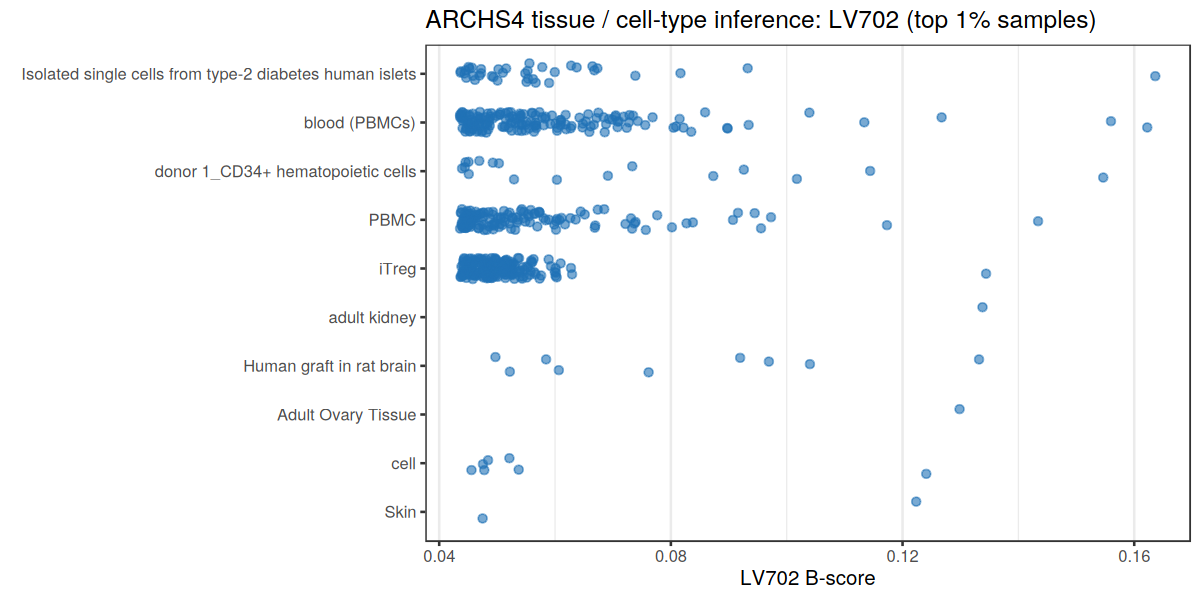

In [13]:
# Strip / jitter plot: mirrors PhenoPlier's sns.catplot(kind='strip')
# x = cell type / tissue, y = LV B-score; samples are individual points.
options(repr.plot.width = 10, repr.plot.height = 5)

ggplot2::ggplot(strip_data, ggplot2::aes(x = cell_type, y = B_score)) +
  ggplot2::geom_jitter(width = 0.22, alpha = 0.6, size = 1.8, colour = "#2171b5") +
  ggplot2::coord_flip() +
  ggplot2::labs(
    title = paste0("ARCHS4 tissue / cell-type inference: ", LV_ID,
                   sprintf(" (top %.0f%% samples)", n_top / length(lv_vec) * 100)),
    x     = NULL,
    y     = paste(LV_ID, "B-score")
  ) +
  ggplot2::theme_bw(base_size = 12) +
  ggplot2::theme(panel.grid.major.y = ggplot2::element_blank())

In [14]:
readr::write_csv(
  strip_data %>% dplyr::select(sample_id, cell_type, B_score, series_id, rank),
  file.path(output_dir, 'lv702_tissue_strip_data.csv')
)
cat('Saved lv702_tissue_strip_data.csv to', output_dir, '\n')

Saved lv702_tissue_strip_data.csv to /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/00_archs4/01_CRISPRCas9/02_tissue_inference 


### Debug: uncategorized samples

Mirrors PhenoPlier's debug section. Samples with `"NOT CATEGORIZED"` have no usable value in `source_name_ch1` or `characteristics_ch1`. Use the `series_id` to look them up at `https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=<GSE_ID>`, then add the inferred label to `label_map` above. Once all are categorised you can filter them out with `dplyr::filter(cell_type != "NOT CATEGORIZED")`.

In [15]:
plot_data %>%
  dplyr::filter(cell_type == "NOT CATEGORIZED") %>%
  dplyr::arrange(dplyr::desc(B_score)) %>%
  dplyr::select(sample_id, series_id, B_score, source_name_ch1, characteristics_ch1) %>%
  dplyr::slice_head(n = 20)

sample_id,series_id,B_score,source_name_ch1,characteristics_ch1
<chr>,<chr>,<dbl>,<chr>,<chr>
